# LP Visitor Intent Segmentation

Runnable notebook version of the take-home analysis. The full reusable implementation lives in `lp_intent.py`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image

import lp_intent as hs

BASE = Path(".")
DATA = BASE / "lp_sessions.csv"
OUTPUTS = BASE / "outputs"
FIGURES = BASE / "figures"

## 1. Load and QA the data

In [2]:
df, qa = hs.load_and_prepare(DATA)
display(qa)
print(df.shape)
display(df.head())

,check,value
0,raw_rows,20040
1,rows_after_exact_dedup,20000
2,exact_duplicate_rows_removed,40
3,duplicate_session_ids_in_raw,40
4,base_lead_rate_after_dedup,0.0439
5,appointments,216
6,appointment_set_missing_rate,0.9561
7,scroll_depth_missing_rate,0.02015
8,time_to_first_scroll_missing_rate,0.015
9,near_instant_bounce_sessions_lt_1s,105


(20000, 22)


,session_id,timestamp,traffic_source,campaign_id,device_type,landing_page_variant,geo_region,returning_visitor,session_duration_sec,scroll_depth_pct,...,time_to_first_scroll_sec,form_started,form_field_interactions,converted,appointment_set,appointment_overall,log_duration,log_clicks,log_time_to_first_scroll,session_date
0,s_672811,2026-02-22 12:55:14,google,g_camp_0011,tablet,A,South,0,13.7,16.4,...,2.77,0,0,0,NaN,0,2.687847,1.386294,1.327075,2026-02-22
1,s_613680,2026-02-26 22:48:48,facebook,fb_camp_0002,mobile,B,South,0,7.8,32.0,...,5.51,0,0,0,NaN,0,2.174752,1.386294,1.873339,2026-02-26
2,s_311500,2026-02-16 18:53:35,facebook,fb_camp_0001,desktop,A,West,0,6.9,16.8,...,4.74,0,0,0,NaN,0,2.066863,1.386294,1.747459,2026-02-16
3,s_094737,2026-03-14 02:34:48,facebook,fb_camp_0002,mobile,A,South,0,68.7,14.3,...,10.54,0,0,0,NaN,0,4.244200,0.693147,2.445819,2026-03-14
4,s_118424,2026-02-25 16:31:56,google,g_camp_0011,desktop,A,South,0,62.0,26.4,...,2.75,0,0,0,NaN,0,4.143135,2.397895,1.321756,2026-02-25


## 2. Compare candidate scoring approaches

The primary segmentation should be behavior-only and pre-form. The richer and leaky models are included as benchmarks/sanity checks.

In [3]:
comparison, predictions = hs.model_comparison(df)
display(comparison)

,model,roc_auc,average_precision,brier_score,log_loss,mean_score,base_rate,n_features_raw
0,behavior_only_pre_form,0.885645,0.312011,0.034988,0.129447,0.043866,0.0439,5
1,behavior_plus_context,0.890446,0.321135,0.034673,0.127678,0.043858,0.0439,10
2,late_stage_leakage_check,0.999354,0.988114,0.003548,0.011752,0.043953,0.0439,12


## 3. Build behavior-based intent tiers

In [4]:
scored, thresholds = hs.add_intent_tiers(df, predictions["behavior_only_pre_form"])
tables = {
    "data_quality_summary": qa,
    "model_comparison": comparison,
    "intent_thresholds": thresholds,
    "behavior_model_coefficients": hs.behavior_coefficients(df),
}
tables.update(hs.summarize_tiers(scored))

display(thresholds)
display(tables["tier_summary"])
display(tables["tier_behavior"])

,threshold,score
0,low_medium_cutoff,0.011510
1,medium_high_cutoff,0.054294


,intent_tier,sessions,session_share,lead_rate,lead_rate_ci95_low,lead_rate_ci95_high,leads,appointment_rate_per_lead,appointment_rate_per_lead_ci95_low,appointment_rate_per_lead_ci95_high,appointments,appointment_rate_per_session,appointment_rate_per_session_ci95_low,appointment_rate_per_session_ci95_high
0,High,4000,0.2,0.172250,0.160864,0.184265,689,0.203193,0.174832,0.234845,140,0.035000,0.029736,0.041156
2,Medium,6000,0.3,0.025333,0.021651,0.029623,152,0.388158,0.314353,0.467477,59,0.009833,0.007631,0.012663
1,Low,10000,0.5,0.003700,0.002686,0.005096,37,0.459459,0.310386,0.616160,17,0.001700,0.001062,0.002721


,intent_tier,score_min,score_median,score_max,duration_median_sec,scroll_median_pct,clicks_median,sections_median,time_to_first_scroll_median_sec,returning_rate,form_start_rate,form_field_interactions_median
0,High,0.054311,0.121661,0.823480,79.70,72.05,7.0,5.0,2.71,0.2220,0.4460,0.0
1,Medium,0.011510,0.022548,0.054289,36.60,46.70,4.0,4.0,3.66,0.1910,0.1920,0.0
2,Low,0.000114,0.003402,0.011510,18.05,20.90,2.0,2.0,5.61,0.1617,0.0656,0.0


### 3b. Robustness check: are near-instant bounce sessions driving the tiers?

In [5]:
tables["tier_summary_excluding_bounces"] = hs.robustness_excluding_bounces(scored)
print("Bounce sessions (<1s):", int((scored["session_duration_sec"] < hs.BOUNCE_DURATION_THRESHOLD_SEC).sum()))
display(tables["tier_summary_excluding_bounces"])

Bounce sessions (<1s): 105


,intent_tier,sessions,session_share,lead_rate,lead_rate_ci95_low,lead_rate_ci95_high,leads,appointment_rate_per_lead,appointment_rate_per_lead_ci95_low,appointment_rate_per_lead_ci95_high,appointments,appointment_rate_per_session,appointment_rate_per_session_ci95_low,appointment_rate_per_session_ci95_high
0,High,4000,0.201056,0.172250,0.160864,0.184265,689,0.203193,0.174832,0.234845,140,0.035000,0.029736,0.041156
1,Medium,5983,0.300729,0.025238,0.021558,0.029528,151,0.384106,0.310318,0.463645,58,0.009694,0.007507,0.012511
2,Low,9912,0.498216,0.003733,0.002710,0.005141,37,0.459459,0.310386,0.616160,17,0.001715,0.001071,0.002745


## 4. Landing page variant A vs B

In [6]:
tables["variant_tests"] = hs.add_multiplicity_correction(hs.variant_tests(scored))
tables["variant_adjusted"] = hs.adjusted_variant_read(scored)
tables.update(hs.variant_mix_tables(scored))
tables.update(hs.decile_tables(scored))

display(tables["variant_raw"])
display(tables["variant_tests"])
display(tables["variant_mix_device_type"])
display(tables["variant_adjusted"])

,landing_page_variant,sessions,session_share,lead_rate,lead_rate_ci95_low,lead_rate_ci95_high,leads,appointment_rate_per_lead,appointment_rate_per_lead_ci95_low,appointment_rate_per_lead_ci95_high,appointments,appointment_rate_per_session,appointment_rate_per_session_ci95_low,appointment_rate_per_session_ci95_high
0,A,8808,0.4404,0.045413,0.041260,0.049963,400,0.220000,0.182174,0.263153,88,0.009991,0.008117,0.012292
1,B,11192,0.5596,0.042709,0.039117,0.046615,478,0.267782,0.230053,0.309214,128,0.011437,0.009628,0.013581


,metric,A_rate,B_rate,B_minus_A,B_minus_A_ci95_low,B_minus_A_ci95_high,p_value,p_value_holm_adjusted,significant_after_holm_alpha_0.05
0,lead_conversion,0.045413,0.042709,-0.002704,-0.008444,0.003035,0.352387,0.664990,False
1,appointment_per_session,0.009991,0.011437,0.001446,-0.001417,0.004308,0.332495,0.664990,False
2,appointment_per_lead,0.220000,0.267782,0.047782,-0.008996,0.104560,0.101903,0.305708,False


,landing_page_variant,device_type,sessions,share
0,A,desktop,4403,0.499886
1,B,desktop,1987,0.177538
2,A,mobile,3705,0.420640
3,B,mobile,8899,0.795122
4,A,tablet,700,0.079473
5,B,tablet,306,0.027341


,metric,adjusted_A_rate,adjusted_B_rate,adjusted_B_minus_A,odds_ratio_B_vs_A,or_ci95_low,or_ci95_high,p_value
0,lead_conversion,0.035088,0.054936,0.019848,1.663987,1.426962,1.940383,8.308191e-11
1,appointment_per_session,0.007731,0.014813,0.007082,1.944649,1.449255,2.609381,9.275856e-06


### 4b. Is variant B a phased rollout, or a concurrent split?

In [7]:
weekly, trend = hs.variant_temporal_stability(scored)
tables["variant_b_weekly_share"] = weekly
tables["variant_b_temporal_trend_test"] = trend
display(weekly)
display(trend)

,week,sessions,b_share
0,2026-02-02/2026-02-08,2588,0.563369
1,2026-02-09/2026-02-15,2479,0.564744
2,2026-02-16/2026-02-22,2555,0.554207
3,2026-02-23/2026-03-01,2530,0.547826
4,2026-03-02/2026-03-08,2548,0.557300
5,2026-03-09/2026-03-15,2559,0.560766
6,2026-03-16/2026-03-22,2596,0.562018
7,2026-03-23/2026-03-29,2145,0.567832


,check,coef_per_day,p_value,overall_B_share,min_weekly_B_share,max_weekly_B_share
0,variant_B_share_trend_over_time,0.000089,0.920641,0.5596,0.547826,0.567832


## 5. Lead quality by source and segment

In [8]:
display(tables["source_quality"])
display(tables["tier_by_source"])

,traffic_source,sessions,session_share,lead_rate,lead_rate_ci95_low,lead_rate_ci95_high,leads,appointment_rate_per_lead,appointment_rate_per_lead_ci95_low,appointment_rate_per_lead_ci95_high,appointments,appointment_rate_per_session,appointment_rate_per_session_ci95_low,appointment_rate_per_session_ci95_high
0,facebook,11944,0.5972,0.012224,0.010404,0.014357,146,0.513699,0.433319,0.593376,75,0.006279,0.005013,0.007863
1,google,8056,0.4028,0.090864,0.084781,0.097337,732,0.192623,0.165689,0.222766,141,0.017502,0.014860,0.020605


,intent_tier,traffic_source,sessions,session_share,lead_rate,lead_rate_ci95_low,lead_rate_ci95_high,leads,appointment_rate_per_lead,appointment_rate_per_lead_ci95_low,appointment_rate_per_lead_ci95_high,appointments,appointment_rate_per_session,appointment_rate_per_session_ci95_low,appointment_rate_per_session_ci95_high
0,High,facebook,843,0.04215,0.086595,0.069436,0.107505,73,0.438356,0.330453,0.552422,32,0.037960,0.027015,0.053096
1,High,google,3157,0.15785,0.195122,0.181672,0.209313,616,0.175325,0.147335,0.207339,108,0.034210,0.028414,0.041138
2,Medium,facebook,3175,0.15875,0.016693,0.012785,0.021769,53,0.584906,0.450944,0.707391,31,0.009764,0.006887,0.013825
3,Medium,google,2825,0.14125,0.035044,0.028870,0.042481,99,0.282828,0.203520,0.378361,28,0.009912,0.006866,0.014288
4,Low,facebook,7926,0.39630,0.002523,0.001634,0.003895,20,0.600000,0.386582,0.781193,12,0.001514,0.000866,0.002645
5,Low,google,2074,0.10370,0.008197,0.005124,0.013088,17,0.294118,0.132800,0.531331,5,0.002411,0.001030,0.005631


## 6. Real-time scoring prototype

`lp_sessions.csv` is one row per completed session, not an event log, so there is no true
sub-session ground truth here. This section demonstrates how the pre-form design would be
implemented: `RealtimeIntentScorer` scores a session in progress using the same fitted
behavior-only pipeline, and `simulate_realtime_trajectories` replays a handful of real
completed sessions as if their behavior accumulated proportionally to elapsed time, purely
to show the shape of a live score - not to validate real-time accuracy.

In [9]:
final_pipeline = hs.fit_final_behavior_pipeline(df)
thresh = thresholds.set_index("threshold")["score"]
scorer = hs.RealtimeIntentScorer(
    final_pipeline,
    low_medium_cutoff=thresh["low_medium_cutoff"],
    medium_high_cutoff=thresh["medium_high_cutoff"],
)
tables["realtime_scoring_demo"] = hs.simulate_realtime_trajectories(scored, scorer)
display(tables["realtime_scoring_demo"])

,session_id,outcome_label,final_intent_tier,checkpoint_frac_of_session,elapsed_sec,score,live_tier
0,s_757669,became_lead,High,0.2,12.54,0.002596,Low
1,s_757669,became_lead,High,0.4,25.08,0.016149,Medium
2,s_757669,became_lead,High,0.6,37.62,0.055380,High
3,s_757669,became_lead,High,0.8,50.16,0.206091,High
4,s_757669,became_lead,High,1.0,62.70,0.437154,High
5,s_189859,became_lead,Medium,0.2,3.60,0.000701,Low
6,s_189859,became_lead,Medium,0.4,7.20,0.001875,Low
7,s_189859,became_lead,Medium,0.6,10.80,0.002777,Low
8,s_189859,became_lead,Medium,0.8,14.40,0.007748,Low
9,s_189859,became_lead,Medium,1.0,18.00,0.014968,Medium


## 7. Save outputs and figures

In [10]:
hs.save_all(scored, tables, OUTPUTS)
hs.make_figures(tables, FIGURES)
print("Saved outputs to", OUTPUTS.resolve())
print("Saved figures to", FIGURES.resolve())

Saved outputs to /Users/baja01/Desktop/lp-intent/outputs
Saved figures to /Users/baja01/Desktop/lp-intent/figures


## 8. Key charts

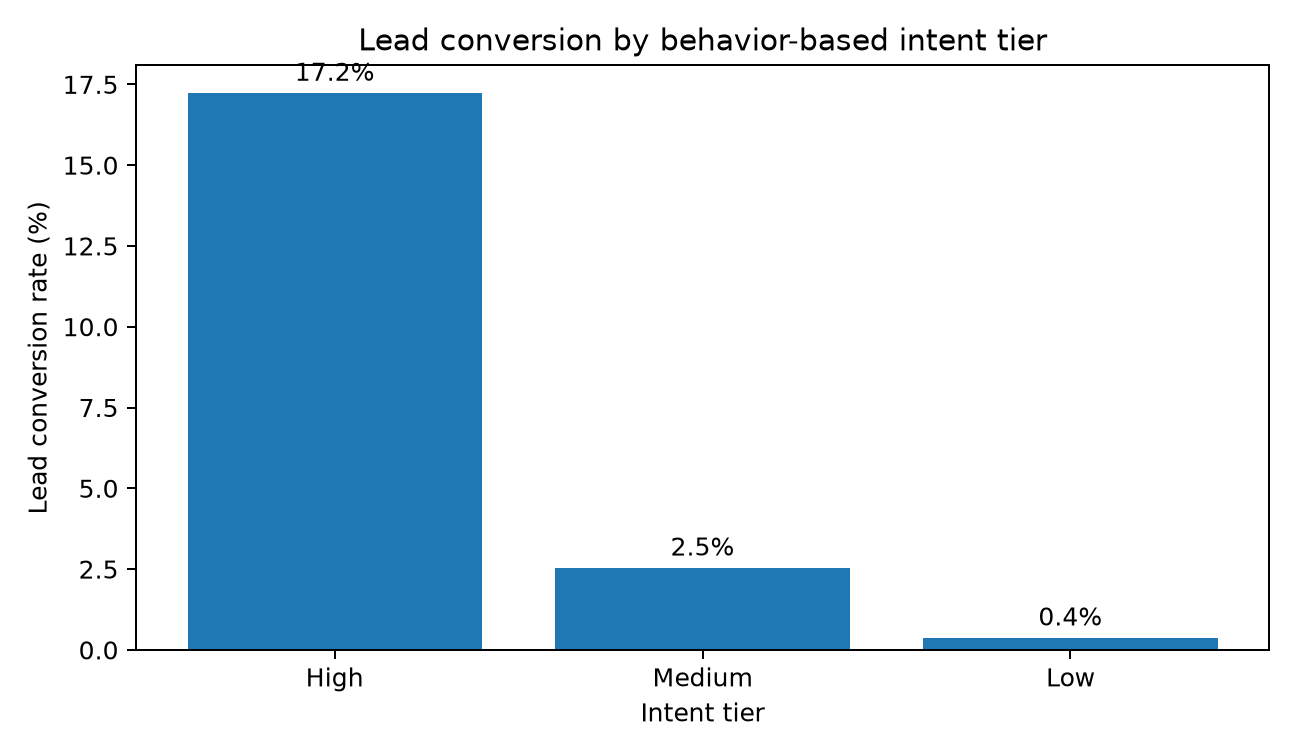

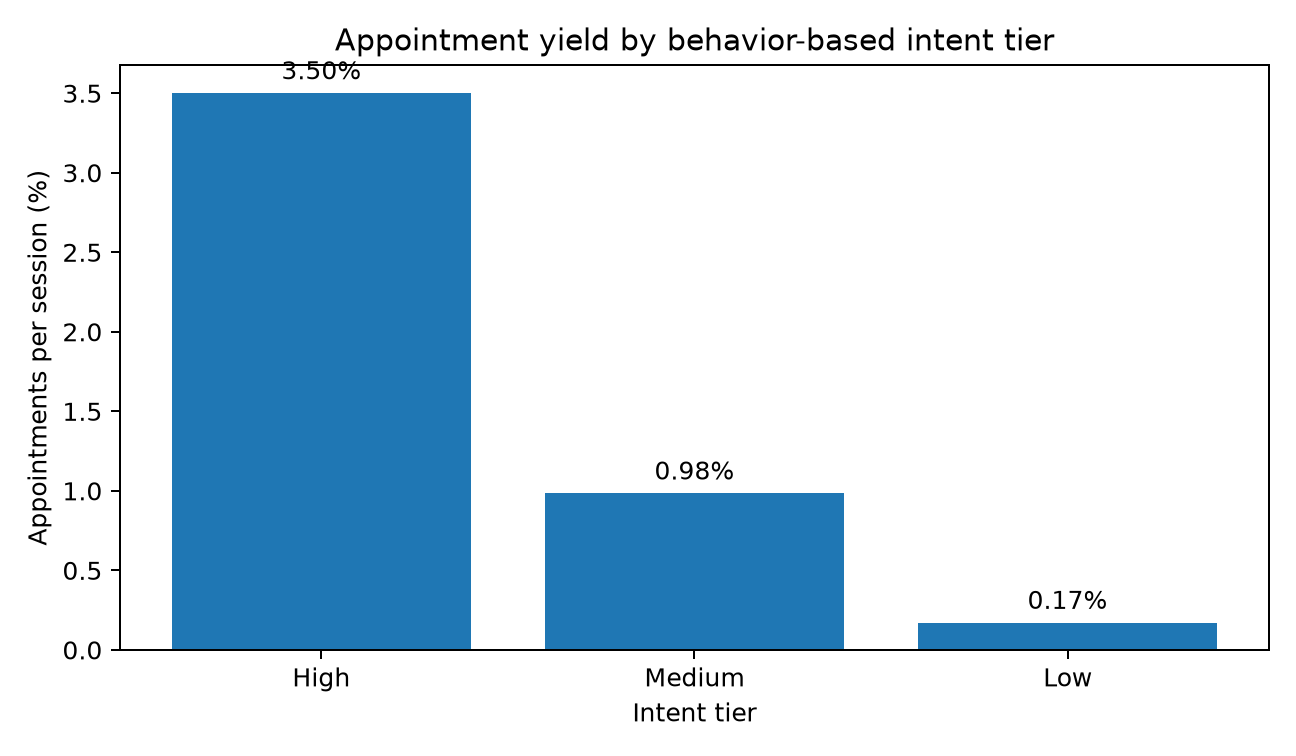

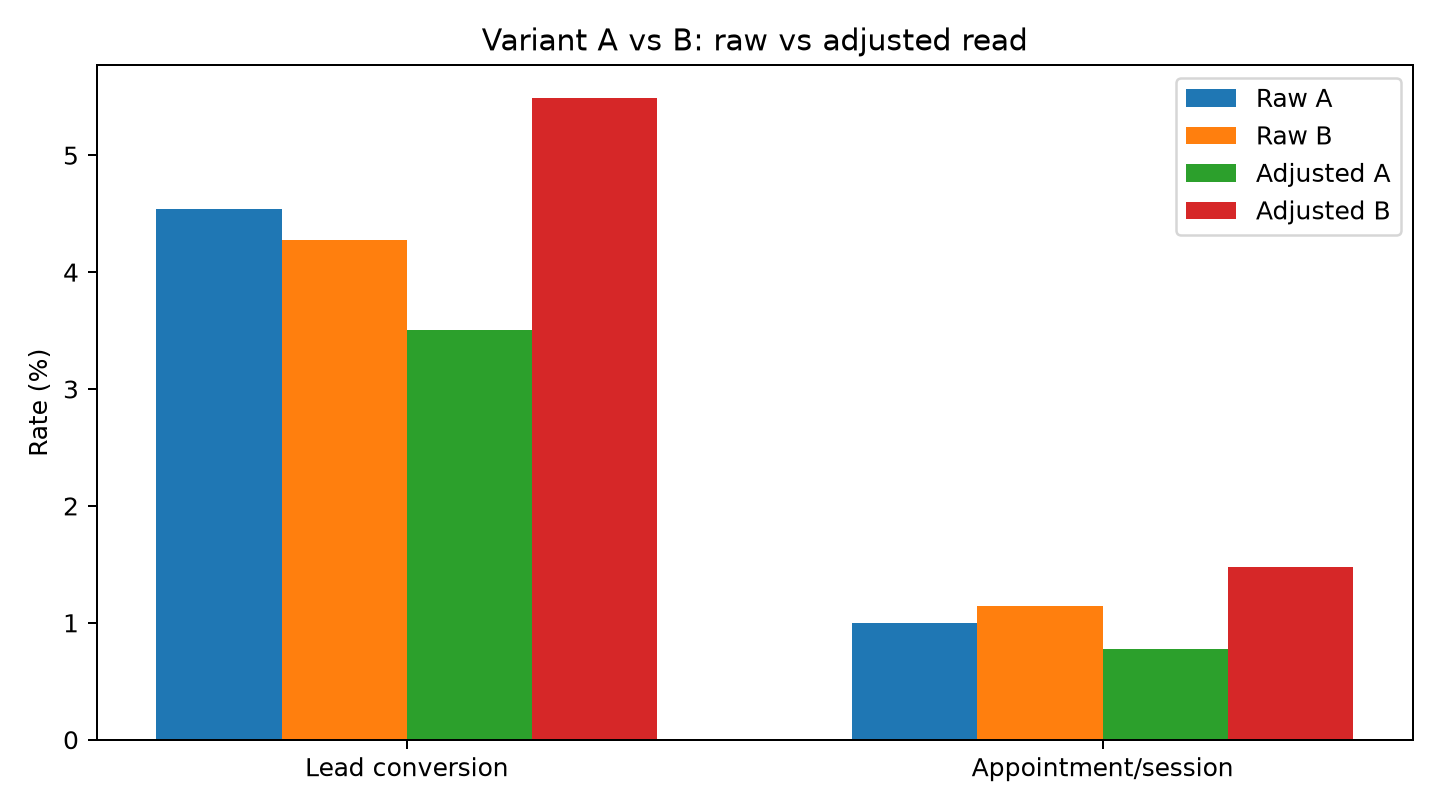

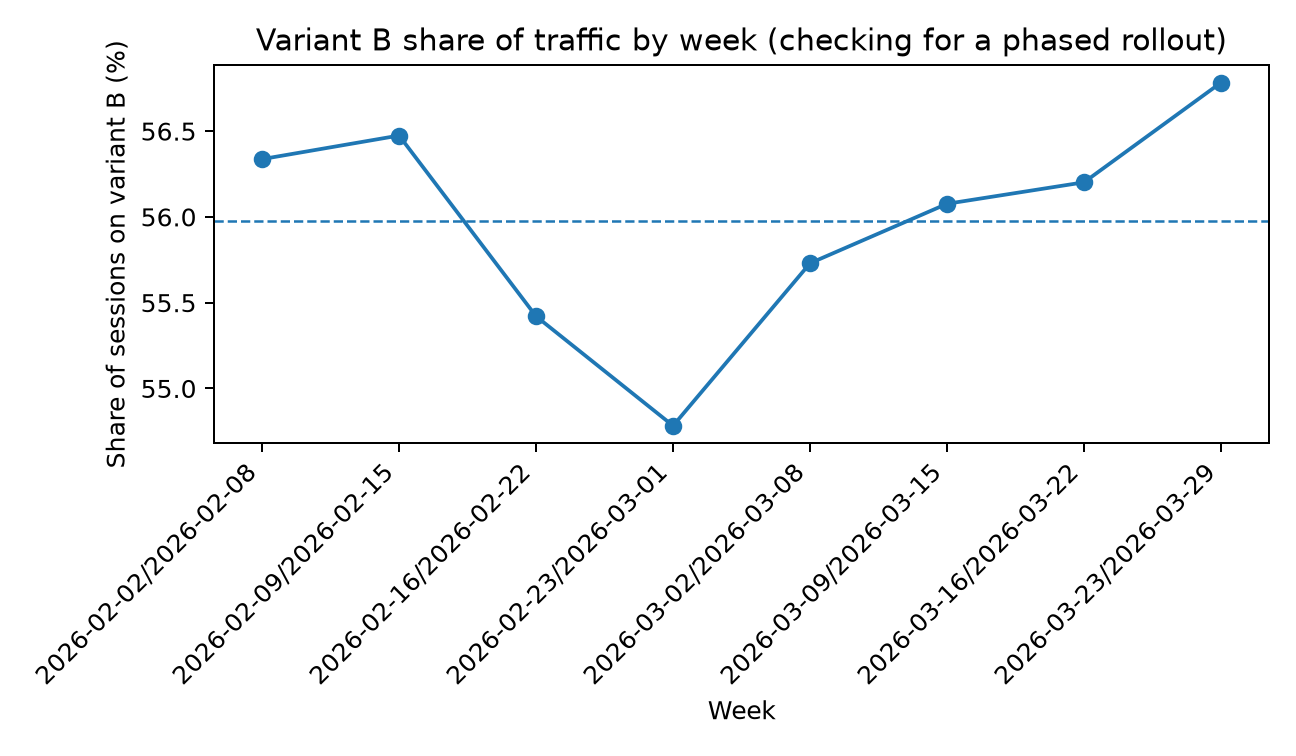

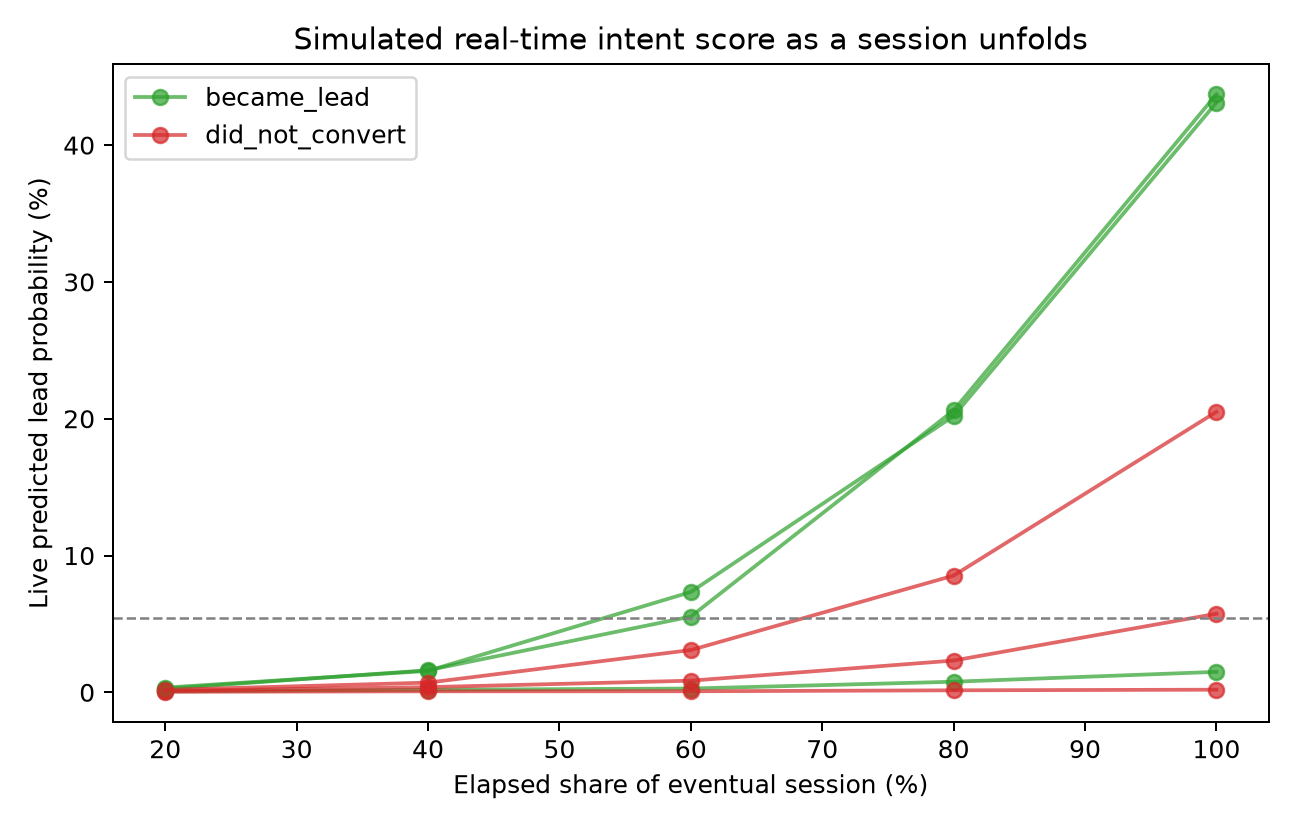

In [11]:
display(Image(filename=str(FIGURES / "conversion_by_intent_tier.png")))
display(Image(filename=str(FIGURES / "appointment_yield_by_intent_tier.png")))
display(Image(filename=str(FIGURES / "variant_raw_vs_adjusted.png")))
display(Image(filename=str(FIGURES / "variant_b_share_over_time.png")))
display(Image(filename=str(FIGURES / "realtime_scoring_trajectories.png")))